In [ ]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.font_manager as fm

font_path = "figutils/Helvetica.ttf"
bold_font_path = "figutils/Helvetica Bold.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()
print(font_name)

if bold_font_path is not None:
    fm.fontManager.addfont(bold_font_path)
    bold_font_name = fm.FontProperties(fname=bold_font_path).get_name()
else:
    bold_font_name = font_name

plt.rcParams["font.family"] = font_name
plt.rcParams["mathtext.fontset"] = "custom"
plt.rcParams["mathtext.rm"] = font_name
plt.rcParams["mathtext.bf"] = f"{bold_font_name}:bold"

Helvetica


In [ ]:
# =============================================================================
# Configuration
# =============================================================================
DEFAULT_SIZE_LEVELS = {
    'Low':  {'thresh': 1_000,        'size': 30,  'label': '< 1k'},
    'Mid':  {'thresh': 50_000,       'size': 100, 'label': '1k – 50k'},
    'High': {'thresh': float('inf'), 'size': 200, 'label': '> 50k'},
}

# =============================================================================
# Data Loading
# =============================================================================

def load_token_frequencies(data_bin_path, token_offset=0):
    """
    Compute per-token frequencies from a binary training dataset.

    Returns
    -------
    dict : token_id → count
    """
    COMPOSITE_DTYPE = np.dtype([
        ('ID',    np.uint32),
        ('AGE',   np.uint32),
        ('DATA',  np.uint32),
        ('SHIFT', np.float32),
        ('TOTAL', np.uint32),
    ])

    print(f"[INFO] Computing token frequencies from: {data_bin_path} (token_offset={token_offset})")
    if not os.path.exists(data_bin_path):
        print("[WARN] Dataset file not found. Returning empty counts.")
        return {}

    data_raw = np.fromfile(data_bin_path, dtype=COMPOSITE_DTYPE)
    tokens = data_raw['DATA'] + int(token_offset)
    unique, counts = np.unique(tokens, return_counts=True)
    token_counts = dict(zip(unique.tolist(), counts.tolist()))
    print(f"[OK]  {len(token_counts)} unique tokens")
    return token_counts


def load_chapter_metadata(csv_path, start_token_id=22):
    """
    Load token-to-chapter metadata CSV.

    Returns
    -------
    token_meta : dict  (token_id → {name, chapter_short, color, …})
    legend_info : pd.DataFrame  (unique chapter_short + color)
    """
    print(f"[INFO] Loading chapter metadata from: {csv_path}")
    df = pd.read_csv(csv_path, header=None)

    if df.shape[1] == 6:
        df.columns = ['raw_idx', 'name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    elif df.shape[1] == 5:
        df.columns = ['name', 'token_id', 'chapter_full', 'chapter_short', 'color']
    else:
        raise ValueError(f"Unexpected column count: {df.shape[1]}")

    df['token_id'] = pd.to_numeric(df['token_id'], errors='coerce')
    df = df.dropna(subset=['token_id'])
    df['token_id'] = df['token_id'].astype(int)

    filtered = df[df['token_id'] >= start_token_id].copy()
    token_meta = filtered.set_index('token_id').to_dict('index')
    legend_info = filtered[['chapter_short', 'color']].drop_duplicates()

    return token_meta, legend_info

# =============================================================================
# Embedding Extraction
# =============================================================================

def load_neutral_total(data_bin_path, total_vocab_size=None):
    """
    Compute a neutral TOTAL token from data (rounded mean of observed TOTAL values).
    """
    COMPOSITE_DTYPE = np.dtype([
        ('ID',    np.uint32),
        ('AGE',   np.uint32),
        ('DATA',  np.uint32),
        ('SHIFT', np.float32),
        ('TOTAL', np.uint32),
    ])

    print(f"[INFO] Computing neutral TOTAL from: {data_bin_path}")
    if not os.path.exists(data_bin_path):
        print("[WARN] Dataset file not found. Using neutral TOTAL token = 0.")
        return 0

    data_raw = np.fromfile(data_bin_path, dtype=COMPOSITE_DTYPE)
    total_vals = data_raw['TOTAL'].astype(np.int64)
    total_vals = total_vals[np.isfinite(total_vals)]
    mean_total = int(np.rint(total_vals.mean())) if len(total_vals) else 0
    if total_vocab_size is not None:
        mean_total = int(np.clip(mean_total, 0, int(total_vocab_size) - 1))
    print(f"[OK]  neutral TOTAL token = {mean_total}")
    return mean_total


def get_embeddings(
    ckpt_path,
    token_meta,
    repr_mode='projected_data_only',
    neutral_total=0,
    neutral_shift=0,
    model=None,
):
    """
    Extract token representations from a trained checkpoint.

    Returns
    -------
    embeddings : np.ndarray  (n_tokens, n_embd)
    valid_token_ids : list[int]
    token_offset : int
    """
    if model is None:
        from figutils.common import load_model
        print(f"[INFO] Loading embeddings from {ckpt_path}")
        model, ckpt = load_model(ckpt_path, device='cpu')
    else:
        print(f"[INFO] Using preloaded model for embeddings from {ckpt_path}")

    token_offset = 1 if bool(getattr(model.config, 'apply_token_shift', False)) else 0
    valid_ids = sorted(token_meta.keys())
    token_ids = torch.tensor(valid_ids, dtype=torch.long)

    with torch.no_grad():
        data_emb = model.composite_emb.data_emb.weight.detach()
        if repr_mode == 'raw':
            emb = data_emb[token_ids]
        elif repr_mode == 'projected_data_only':
            n_embd = data_emb.shape[1]
            proj_weight = model.composite_emb.proj.weight.detach()
            proj_data = proj_weight[:, :n_embd]
            emb = data_emb[token_ids] @ proj_data.T
        elif repr_mode == 'projected_fixed_context':
            shift_dummy = torch.full_like(token_ids, int(neutral_shift))
            total_dummy = torch.full_like(token_ids, int(neutral_total))
            emb = model.composite_emb(token_ids, shift_dummy, total_dummy)
        else:
            raise ValueError(
                f"Unknown repr_mode={repr_mode!r}. "
                "Choose from {'raw', 'projected_data_only', 'projected_fixed_context'}."
            )

    print(f"[INFO] Representation mode: {repr_mode}")
    return emb.detach().cpu().numpy(), valid_ids, token_offset


# =============================================================================
# UMAP & Plotting
# =============================================================================

def run_umap(embeddings, n_neighbors=30, min_dist=0.05, metric='cosine'):
    """Run UMAP dimensionality reduction → (N, 2) array."""
    print("[INFO] Running UMAP...")
    reducer = umap.UMAP(
        n_neighbors=n_neighbors, min_dist=min_dist,
        metric=metric, random_state=42,
    )
    return reducer.fit_transform(embeddings)

In [5]:
# from figutils.umap_viz import (
#     load_token_frequencies, load_chapter_metadata,
#     get_embeddings, run_umap, draw_umap_plot
# )

CKPT_PATH   = '../out/0506/ckpt.pt'
LABELS_PATH = '../../data/labels_chapter.csv'
TRAIN_BIN   = '../../data/kr_train.bin'
REPR_MODE   = 'raw'  # options: raw | projected_data_only | projected_fixed_context
MIN_EVENT_COUNT = 25  # 0이면 event 수 100회 미만 token도 모두 표시

# 라벨링할 토큰 ID
# TARGET_IDS = [224, 225, 1285, 1286, 1289]#[224,1278,1279,1280,1281,1282,1283,1284,1285,1286,1287,1288,1289 ]  
#[223,224,225,226,227,508,879,1177, 1278,1279,1280,1281,1282,1283,1284,1285,1286,1287,1288,1289]

# 데이터 준비
from figutils.common import load_model

token_meta, legend_info = load_chapter_metadata(LABELS_PATH)
model, _ = load_model(CKPT_PATH, device='cpu')
token_offset = 1 if bool(getattr(model.config, 'apply_token_shift', False)) else 0
neutral_total = load_neutral_total(
    TRAIN_BIN,
    total_vocab_size=getattr(model.config, 'total_vocab_size', None),
)

embeddings, valid_ids, token_offset = get_embeddings(
    CKPT_PATH,
    token_meta,
    repr_mode=REPR_MODE,
    neutral_total=neutral_total,
    neutral_shift=0,
    model=model,
)
token_counts = load_token_frequencies(TRAIN_BIN, token_offset=token_offset)
umap_2d = run_umap(embeddings, n_neighbors=30, min_dist=0.05)
print(f'[INFO] UMAP representation mode: {REPR_MODE}')

[INFO] Loading chapter metadata from: ../../data/labels_chapter.csv
[INFO] Loading model from ../out/0506/ckpt.pt → cpu
[INFO] Detected BinaryChangeHead → using model_v2
[OK]  Model loaded (36.90M params)
[INFO] Computing neutral TOTAL from: ../../data/kr_train.bin
[OK]  neutral TOTAL token = 7
[INFO] Using preloaded model for embeddings from ../out/0506/ckpt.pt
[INFO] Representation mode: raw
[INFO] Computing token frequencies from: ../../data/kr_train.bin (token_offset=0)
[OK]  1156 unique tokens
[INFO] Running UMAP...


/home/hsh/miniconda3/envs/hsh/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[INFO] UMAP representation mode: raw


In [6]:
desired_order = [
    'I. Infectious Diseases',
    'II. Neoplasms',
    'III. Blood & Immune Disorders',
    'IV. Metabolic Diseases',
    'V. Mental Disorders',
    'VI. Nervous System Diseases',
    'VII. Eye Diseases',
    'VIII. Ear Diseases',
    'IX. Circulatory Diseases',
    'X. Respiratory Diseases',
    'XI. Digestive Diseases',
    'XII. Skin Diseases',
    'XIII. Musculoskeletal Diseases',
    'XIV. Genitourinary Diseases',
    'XV. Pregnancy & Childbirth',
    'XVI. Perinatal Conditions',
    'XVII. Congenital Abnormalities',
    'XX. Diabetes drugs',
    'Death'
]

legend_info['chapter_short'] = pd.Categorical(
    legend_info['chapter_short'],
    categories=desired_order,
    ordered=True
)

legend_info = legend_info.sort_values('chapter_short').reset_index(drop=True)
legend_info

,chapter_short,color
0,I. Infectious Diseases,#98df8a
1,II. Neoplasms,#ff7f0e
2,III. Blood & Immune Disorders,#ff9896
3,IV. Metabolic Diseases,#2ca02c
4,V. Mental Disorders,#9edae5
5,VI. Nervous System Diseases,#7f7f7f
6,VII. Eye Diseases,#aec7e8
7,VIII. Ear Diseases,#dbdb8d
8,IX. Circulatory Diseases,#d62728
9,X. Respiratory Diseases,#17becf


In [7]:
legend_info.loc[0, 'color'] = '#91c987' ### I. Infectious Diseases
legend_info.loc[1, 'color'] = '#ec713f' ### II. Neoplasms
legend_info.loc[2, 'color'] = '#dd5752' ### III. Blood & Immune Disorders
legend_info.loc[3, 'color'] = '#4f7951' ### IV. Metabolic Diseases
legend_info.loc[4, 'color'] = '#90c0c2' ### V. Mental Disorders
legend_info.loc[5, 'color'] = '#87776a' ### VI. Nervous System Diseases
# legend_info.loc[6, 'color'] = '#87776a' ### VII. Eye Diseases
legend_info.loc[7, 'color'] = '#e6c186' ### VIII. Ear Diseases	
legend_info.loc[8, 'color'] = '#c34a54' ### IX. Circulatory Diseases
legend_info.loc[9, 'color'] = '#567797' ### X. Respiratory Diseases
legend_info.loc[10, 'color'] = '#6b512a' ### XI. Digestive Diseases
# legend_info.loc[11, 'color'] = '#' ### XII. Skin Diseases
legend_info.loc[12, 'color'] = '#2964b8' ### XIII. Musculoskeletal Diseases
legend_info.loc[13, 'color'] = '#f7b141' ### XIV. Genitourinary Diseases
legend_info.loc[14, 'color'] = '#e45c88' ### XV. Pregnancy & Childbirth
# legend_info.loc[15, 'color'] = '#d08b32' ### XVI. Perinatal Conditions
# legend_info.loc[16, 'color'] = '#e45c88' ### XVII. Congenital Abnormalities
if pd.api.types.is_categorical_dtype(legend_info['chapter_short']):
    if 'Diabetes Drugs' not in legend_info['chapter_short'].cat.categories:
        legend_info['chapter_short'] = legend_info['chapter_short'].cat.add_categories(['Diabetes Drugs'])
legend_info.loc[17, 'color'] = '#E7C547' ### Medication for Diabetes
legend_info.loc[17, 'chapter_short'] = 'Diabetes Drugs'
legend_info.loc[18, 'color'] = '#1d1f20' ### Death

for k, v in token_meta.items():
    if v['color'] == '#98df8a':
        token_meta[k]['color'] = "#91c987"
    elif v['color'] == '#ff7f0e':
        token_meta[k]['color'] = '#ec713f'
    elif v['color'] == '#ff9896':
        token_meta[k]['color'] = "#dd5752"
    elif v['color'] == '#2ca02c':
        token_meta[k]['color'] = "#4f7951"
    elif v['color'] == '#9edae5':
        token_meta[k]['color'] = '#90c0c2'
    elif v['color'] == '#7f7f7f':
        token_meta[k]['color'] = '#87776a'
        
    elif v['color'] == '#dbdb8d':
        token_meta[k]['color'] = '#e6c186'
    elif v['color'] == '#d62728':
        token_meta[k]['color'] = '#c34a54'
    elif v['color'] == '#17becf':
        token_meta[k]['color'] = '#567797'
    elif v['color'] == '#1f77b4':
        token_meta[k]['color'] = '#2964b8'
    elif v['color'] == '#8c564b':
        token_meta[k]['color'] = '#6b512a'
    elif v['color'] == '#ffbb78':
        token_meta[k]['color'] = '#f7b141'
    elif v['color'] == '#e377c2':
        token_meta[k]['color'] = '#e45c88'
    elif v['color'] == '#FFFF00':
        token_meta[k]['color'] = '#E7C547'
        token_meta[k]['chapter_short'] = 'Diabetes Drugs'
    elif v['color'] == '#000a35':
        token_meta[k]['color'] = '#1d1f20'
        

/tmp/ipykernel_1960017/3715670523.py:18: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(legend_info['chapter_short']):


In [8]:
legend_info

,chapter_short,color
0,I. Infectious Diseases,#91c987
1,II. Neoplasms,#ec713f
2,III. Blood & Immune Disorders,#dd5752
3,IV. Metabolic Diseases,#4f7951
4,V. Mental Disorders,#90c0c2
5,VI. Nervous System Diseases,#87776a
6,VII. Eye Diseases,#aec7e8
7,VIII. Ear Diseases,#e6c186
8,IX. Circulatory Diseases,#c34a54
9,X. Respiratory Diseases,#567797


In [111]:
def draw_umap_plot(embedding_2d, valid_token_ids, token_meta,
                   token_counts, legend_info,
                   target_label_ids=None, size_levels=None,
                   figsize=(12, 8), save_path=None,
                   min_event_count=0, inset_configs=None):

    if size_levels is None:
        size_levels = DEFAULT_SIZE_LEVELS

    if inset_configs is None:
        inset_configs = [
            {
                'title': 'Diabetes-related conditions',
                'target_id': 224,  # E11
                'prefixes': ('E10', 'E11', 'E16', 'G63', 'H36', 'I79'),
                'label_token_ids': (224, 225, 226, 227, 409, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287),
                'host': 'main',
                'x_radius': 0.68,
                'y_radius': 0.7,
                'center_offset': (0.12, -0.60),
                'bounds': [0.05, 0.05, 0.28, 0.32],
                'max_labels': 11,
                'description_position': 'below',
                'max_description_labels': 11,
                'include_token_ids': (409,),  # Force G63 into the inset window.
                # 'report_distances_to_ids': (224, 225, 226, 227, 456, 457, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289),
            },
            {
                'title': 'Critical conditions',
                'host': 'main',
                'target_keyword': 'death',
                'prefixes': ('A40', 'A41', 'I21', 'I46'),
                'keywords': ('death',),
                'label_token_ids': (54, 55, 282, 514, 519, 538, 542, 547, 623, 878, 1288),
                'include_token_ids': (54, 55, 282, 514, 519, 538, 542, 547, 623, 878, 1288),
                'radius': 0.25,
                'bounds': [0.86, 0.04, 0.27, 0.23],
                'max_labels': 10,
                'description_position': 'right',
                'max_description_labels': 10,
                'connector_corners': [((0, 0), 'lower_left'), ((1, 1), 'upper_right')],
                # 'report_distances_to_ids': (1288, 54, 55, 514, 538),
            },
            {
                'title': 'Cancer-related conditions',
                'target_id': 1174,  # C22
                'prefixes': ('C18', 'C19', 'C20', 'C22', 'C23', 'C24', 'C25', 'C34', 'C50', 'C54', 'C67', 'C77', 'C78', 'C79', 'C80'),
                'label_token_ids': (1170, 1171, 1172, 1174, 1175, 1176, 1177, 1183, 1197, 1201, 1213, 1223, 1224, 1225, 1226),
                'include_token_ids': (1170, 1171, 1172, 1174, 1175, 1176, 1177, 1183, 1197, 1201, 1213, 1223, 1224, 1225, 1226),
                'host': 'main',
                'x_radius': 0.05,
                'y_radius': 0.25,
                'center_offset': (0, -0.05),
                'include_pad_x': 0.0,
                'include_pad_y': 0.02,
                'bounds': [1.0, 0.70, 0.30, 0.24],
                'max_labels': 11,
                'description_position': 'above',
                'max_description_labels': 11,
            },
            # {
            #     'title': 'CKD / renal complications',
            #     'host': 'main',
            #     'target_prefix': 'N18',
            #     'prefixes': ('N18', 'N08', 'E11.2', 'I12', 'I13'),
            #     'keywords': ('renal', 'kidney', 'nephropathy'),
            #     'radius': 0.72,
            #     'bounds': [0.40, 0.04, 0.28, 0.24],
            #     'max_labels': 8,
            # },
        ]

    print("[INFO] Rendering UMAP scatter plot...")

    df = pd.DataFrame(embedding_2d, columns=['x', 'y'])
    df['token_id'] = valid_token_ids
    df['color'] = [token_meta[t]['color'] for t in valid_token_ids]
    df['name'] = [token_meta[t]['name'] for t in valid_token_ids]
    df['chapter_short'] = [token_meta[t]['chapter_short'] for t in valid_token_ids]
    df['count'] = [token_counts.get(t, 0) for t in valid_token_ids]
    df['code'] = df['name'].astype(str).str.split().str[0].str.upper()

    if min_event_count and min_event_count > 0:
        n_before = len(df)
        df = df[df['count'] >= min_event_count].copy()
        print(f"[INFO] Kept {len(df)}/{n_before} tokens with count >= {min_event_count}")

    sizes = []
    alphas = []
    alpha_levels = {
        'Low': 0.3,
        'Mid': 0.70,
        'High': 0.90,
    }
    for c in df['count']:
        if c < size_levels['Low']['thresh']:
            sizes.append(size_levels['Low']['size'])
            alphas.append(alpha_levels['Low'])
        elif c < size_levels['Mid']['thresh']:
            sizes.append(size_levels['Mid']['size'])
            alphas.append(alpha_levels['Mid'])
        else:
            sizes.append(size_levels['High']['size'])
            alphas.append(alpha_levels['High'])
    df['size'] = sizes
    df['alpha'] = alphas

    def _draw_points(axis, data, scale=1.0, highlight=None, emphasis_token_ids=()):
        emphasis_token_ids = set(emphasis_token_ids)
        for zorder, sz in enumerate(sorted(data['size'].unique()), start=1):
            sub = data[data['size'] == sz]
            if emphasis_token_ids:
                sub_groups = [
                    (sub[~sub['token_id'].isin(emphasis_token_ids)], float(sub['alpha'].iloc[0]), zorder),
                    (sub[sub['token_id'].isin(emphasis_token_ids)], 0.9, zorder + 10),
                ]
            else:
                sub_groups = [(sub, float(sub['alpha'].iloc[0]), zorder)]
            for sub_part, alpha, part_zorder in sub_groups:
                if sub_part.empty:
                    continue
                axis.scatter(
                    sub_part['x'], sub_part['y'],
                    c=sub_part['color'],
                    s=sub_part['size'] * scale,
                    alpha=alpha,
                    edgecolors='white',
                    linewidth=0.3,
                    zorder=part_zorder,
                )
        if highlight is not None and int(highlight['token_id']) not in emphasis_token_ids:
            axis.scatter(
                [highlight['x']], [highlight['y']],
                c=highlight['color'],
                s=180 * scale,
                alpha=0.9,
                # edgecolors='black',
                # linewidth=1.0,
                zorder=20,
            )

    def _match_target(config):
        if 'target_id' in config:
            hit = df[df['token_id'] == config['target_id']]
        elif 'target_prefix' in config:
            hit = df[df['code'].str.startswith(config['target_prefix'])]
        elif 'target_keyword' in config:
            keyword = config['target_keyword'].lower()
            hit = df[df['name'].str.lower().str.contains(keyword, na=False)]
        else:
            hit = pd.DataFrame()
        if hit.empty:
            return None
        return hit.sort_values('count', ascending=False).iloc[0]

    def _label_mask(data, config):
        prefixes = tuple(config.get('prefixes', ()))
        keywords = tuple(k.lower() for k in config.get('keywords', ()))
        label_token_ids = set(config.get('label_token_ids', ()))
        by_prefix = data['code'].apply(lambda code: any(code.startswith(p) for p in prefixes)) if prefixes else False
        by_keyword = data['name'].str.lower().apply(lambda name: any(k in name for k in keywords)) if keywords else False
        by_token_id = data['token_id'].isin(label_token_ids) if label_token_ids else False
        return by_prefix | by_keyword | by_token_id

    def _label_text(row):
        code = str(row['code'])
        if len(code) >= 2 and code[0].isalpha() and code[1].isdigit():
            return code
        return str(row['name'])

    def _description_text(row):
        code = str(row['code'])
        name = str(row['name'])
        if len(code) >= 2 and code[0].isalpha() and code[1].isdigit() and name.startswith(code):
            return f"{code}: {name[len(code):].strip()}"
        return name

    def _bold_mathtext(text):
        escaped = str(text).replace(' ', r'\ ').replace('-', r'{-}')
        return rf"$\bf{{{escaped}}}$"

    # Main plot + dedicated inset/legend axes.
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 3, width_ratios=[2.15, 4.7, 1.2], wspace=0.06)

    ax_inset_host = fig.add_subplot(gs[0, 0])
    ax_inset_host.axis("off")
    ax = fig.add_subplot(gs[0, 1])
    ax_leg = fig.add_subplot(gs[0, 2])
    ax_leg.axis("off")

    # Larger, more frequent markers are drawn last and with higher alpha.
    _draw_points(ax, df)

    # Draft multi-inset overlay. Tune `bounds` and `radius` per run for final layout.
    try:
        from matplotlib.patches import ConnectionPatch
        for config in inset_configs:
            target = _match_target(config)
            if target is None:
                print(f"[WARN] Inset target not found: {config.get('title', config)}")
                continue

            radius = float(config.get('radius', 0.8))
            x_radius = float(config.get('x_radius', radius))
            y_radius = float(config.get('y_radius', radius))
            offset_x, offset_y = config.get('center_offset', (0.0, 0.0))
            center_x = target['x'] + offset_x
            center_y = target['y'] + offset_y
            x0, x1 = center_x - x_radius, center_x + x_radius
            y0, y1 = center_y - y_radius, center_y + y_radius
            include = df[df['token_id'].isin(config.get('include_token_ids', ()))].copy()
            if not include.empty:
                pad = float(config.get('include_pad', 0.08))
                pad_x = float(config.get('include_pad_x', pad))
                pad_y = float(config.get('include_pad_y', pad))
                x0 = min(x0, include['x'].min() - pad_x)
                x1 = max(x1, include['x'].max() + pad_x)
                y0 = min(y0, include['y'].min() - pad_y)
                y1 = max(y1, include['y'].max() + pad_y)
            local = df[df['x'].between(x0, x1) & df['y'].between(y0, y1)].copy()
            local['dist_to_target'] = np.sqrt((local['x'] - target['x'])**2 + (local['y'] - target['y'])**2)
            labels = local[_label_mask(local, config)].copy()
            explicit_label_ids = set(config.get('label_token_ids', ()))
            labels['is_explicit_label'] = labels['token_id'].isin(explicit_label_ids)
            labels = labels.sort_values(['is_explicit_label', 'dist_to_target'], ascending=[False, True])

            if config.get('report_distances_to_ids'):
                ranked = df.copy()
                ranked['dist_to_target'] = np.sqrt((ranked['x'] - target['x'])**2 + (ranked['y'] - target['y'])**2)
                ranked = ranked.sort_values('dist_to_target').reset_index(drop=True)
                ranked['rank'] = np.arange(1, len(ranked) + 1)
                report = ranked[ranked['token_id'].isin(config['report_distances_to_ids'])]
                print(f"\n[Inset distance report] {config['title']} target={int(target['token_id'])} {target['name']}")
                print(report[['rank', 'token_id', 'name', 'count', 'dist_to_target']].to_string(index=False))

            rect = mpatches.Rectangle(
                (x0, y0), x1 - x0, y1 - y0,
                fill=False,
                linestyle=(0, (4, 3)),
                linewidth=0.7,
                edgecolor='black',
                zorder=30,
            )
            ax.add_patch(rect)

            inset_parent = ax_inset_host if config.get('host', 'left') == 'left' else ax
            ax_inset = inset_parent.inset_axes(config['bounds'])
            _draw_points(
                ax_inset, local, scale=0.75, highlight=target,
                emphasis_token_ids=config.get('label_token_ids', ()),
            )
            ax_inset.set_xlim(x0, x1)
            ax_inset.set_ylim(y0, y1)
            # ax_inset.set_title(config['title'], fontsize=8, loc='left', pad=2)
            texts = []
            label_rows = labels.head(config.get('max_labels', 8)).copy()
            for _, row in label_rows.iterrows():
                texts.append(
                    ax_inset.text(
                        row['x'], row['y'], _label_text(row),
                        fontsize=9, ha='left', va='bottom', zorder=40,
                        clip_on=False,
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.0, pad=0.6),
                    )
                )
            if texts:
                try:
                    from adjustText import adjust_text
                    _, connector_patches = adjust_text(
                        texts,
                        ax=ax_inset,
                        target_x=label_rows['x'].to_numpy(),
                        target_y=label_rows['y'].to_numpy(),
                        arrowprops=dict(
                            arrowstyle='-', color='black', lw=0.4,
                            shrinkA=6, shrinkB=0,
                        ),
                        expand_points=(1.35, 1.45),
                        expand_text=(2.0, 2.2),
                        force_text=(1.3, 1.6),
                        force_static=(0.35, 0.45),
                        force_explode=(0.6, 0.8),
                        explode_radius=80,
                        ensure_inside_axes=False,
                        lim=500,
                    )
                    for patch in connector_patches:
                        patch.set_zorder(45)
                        patch.set_clip_on(False)
                        if hasattr(patch, 'shrinkA'):
                            patch.shrinkA = 6
                        if hasattr(patch, 'shrinkB'):
                            patch.shrinkB = 0
                except ImportError:
                    for text, (_, row) in zip(texts, label_rows.iterrows()):
                        ax_inset.plot(
                            [row['x'], text.get_position()[0]],
                            [row['y'], text.get_position()[1]],
                            color='black', linewidth=0.4, zorder=45,
                        )

            for this_ax in (ax_inset,):
                this_ax.set_aspect('equal')
                this_ax.set_xticks([])
                this_ax.set_yticks([])
                for spine in this_ax.spines.values():
                    spine.set_visible(True)
                    spine.set_linestyle((0, (4, 3)))
                    spine.set_linewidth(0.9)


            corner_lookup = {
                'lower_left': (x0, y0),
                'upper_left': (x0, y1),
                'lower_right': (x1, y0),
                'upper_right': (x1, y1),
            }
            connector_corners = config.get(
                'connector_corners',
                [((0, 1), 'upper_left'), ((1, 0), 'lower_right')],
            )
            for corner_ax, corner_key in connector_corners:
                corner_data = corner_lookup[corner_key]
                con = ConnectionPatch(
                    xyA=corner_ax,
                    coordsA=ax_inset.transAxes,
                    xyB=corner_data,
                    coordsB=ax.transData,
                    axesA=ax_inset,
                    axesB=ax,
                    color='black',
                    linewidth=0.7,
                    zorder=25,
                )
                fig.add_artist(con)

            description_position = config.get('description_position')
            description_xy = config.get('description_xy', config.get('text_xy'))
            if description_position is not None or description_xy is not None:
                title_text = _bold_mathtext(f"{config['title']}:")
                body_text = []
                desc_rows = labels.head(config.get('max_description_labels', config.get('max_text_labels', 5)))
                for _, row in desc_rows.iterrows():
                    body_text.append(_description_text(row))
                description_text = "\n".join([title_text] + body_text)
                if description_position is not None:
                    if description_position == 'above':
                        xy = (0.0, 1.08)
                        va = 'bottom'
                    elif description_position == 'right':
                        xy = (1.08, 1.0)
                        va = 'top'
                    else:
                        xy = (0.0, -0.08)
                        va = 'top'
                    ax_inset.text(
                        xy[0], xy[1], description_text,
                        transform=ax_inset.transAxes,
                        fontsize=config.get('description_fontsize', 9),
                        ha='left', va=va,
                        linespacing=config.get('description_linespacing', 1.0),
                        clip_on=False,
                    )
                else:
                    fig.text(
                        description_xy[0], description_xy[1], description_text,
                        fontsize=config.get('description_fontsize', 9),
                        ha='left',
                        va='top',
                        linespacing=config.get('description_linespacing', 1.0),
                    )
    except Exception as exc:
        print(f"[WARN] Failed to draw insets: {exc}")

    # Annotate selected tokens
    if target_label_ids:
        texts = []
        for _, row in df.iterrows():
            if int(row['token_id']) in target_label_ids:
                t = ax.text(
                    row['x'], row['y'],
                    f"{row['name']} ({int(row['token_id'])})",
                    fontsize=7, fontweight='bold', color='black'
                )
                texts.append(t)
        try:
            from adjustText import adjust_text
            adjust_text(
                texts,
                arrowprops=dict(arrowstyle='-', color='black', lw=0.3),
                ax=ax
            )
        except ImportError:
            pass

    # ---------------------------
    # Legend 1: chapter legend
    # ---------------------------
    patches = [
        mlines.Line2D(
            [], [], linestyle='None',
            marker='o',
            markerfacecolor=r['color'],
            markeredgecolor='black',
            markeredgewidth=0.4,
            markersize=8,
            label=r['chapter_short']
        )
        for _, r in legend_info.iterrows()
    ]

    leg1 = ax_inset_host.legend(
        handles=patches,
        loc='upper left',
        bbox_to_anchor=(0.2, 0.9),
        fontsize=9,
        frameon=False,
        borderaxespad=0.0,
        # linewidth=0.3,
        ncol=1,
        handletextpad=0.4
    )
    ax_inset_host.add_artist(leg1)

    # Draw once to calculate legend size
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    bbox = leg1.get_window_extent(renderer=renderer)

    # Convert legend bbox to ax_leg axes coordinates
    bbox_axes = bbox.transformed(ax_inset_host.transAxes.inverted())

    # ---------------------------
    # Legend 2: frequency legend
    # place directly below chapter legend
    # ---------------------------
    label_size_levels = {
        'Low':  {'thresh': 1_000,        'size': 30,  'label': '< 1k'},
        'Mid':  {'thresh': 50_000,       'size': 100, 'label': '1k – 50k'},
        'High': {'thresh': float('inf'), 'size': 200, 'label': '> 50k'},
    }

    size_handles = [
        mlines.Line2D(
            [], [],
            color='black',
            marker='o',
            # linewidth=0.2,
            linestyle='None',
            markerfacecolor='black',
            alpha=1.0,
            markersize=np.sqrt(label_size_levels[lv]['size']),
            label=label_size_levels[lv]['label']
        )
        for lv in ('Low', 'Mid', 'High')
    ]

    freq_y = bbox_axes.y0 - 0.02  # small gap below chapter legend

    ax_inset_host.legend(
        handles=size_handles,
        loc='upper left',
        bbox_to_anchor=(0.3, freq_y),
        # title='Frequency',
        title_fontsize=9,
        fontsize=9,
        frameon=False,
        borderaxespad=0.0,
        labelspacing=1.02
    )

    # Clean main axis
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.subplots_adjust(left=0.03, right=0.98, top=0.97, bottom=0.05)

    return fig

[INFO] Rendering UMAP scatter plot...
[INFO] Kept 852/1267 tokens with count >= 25
[OK] Saved out/umap.png/.pdf and coordinates CSV


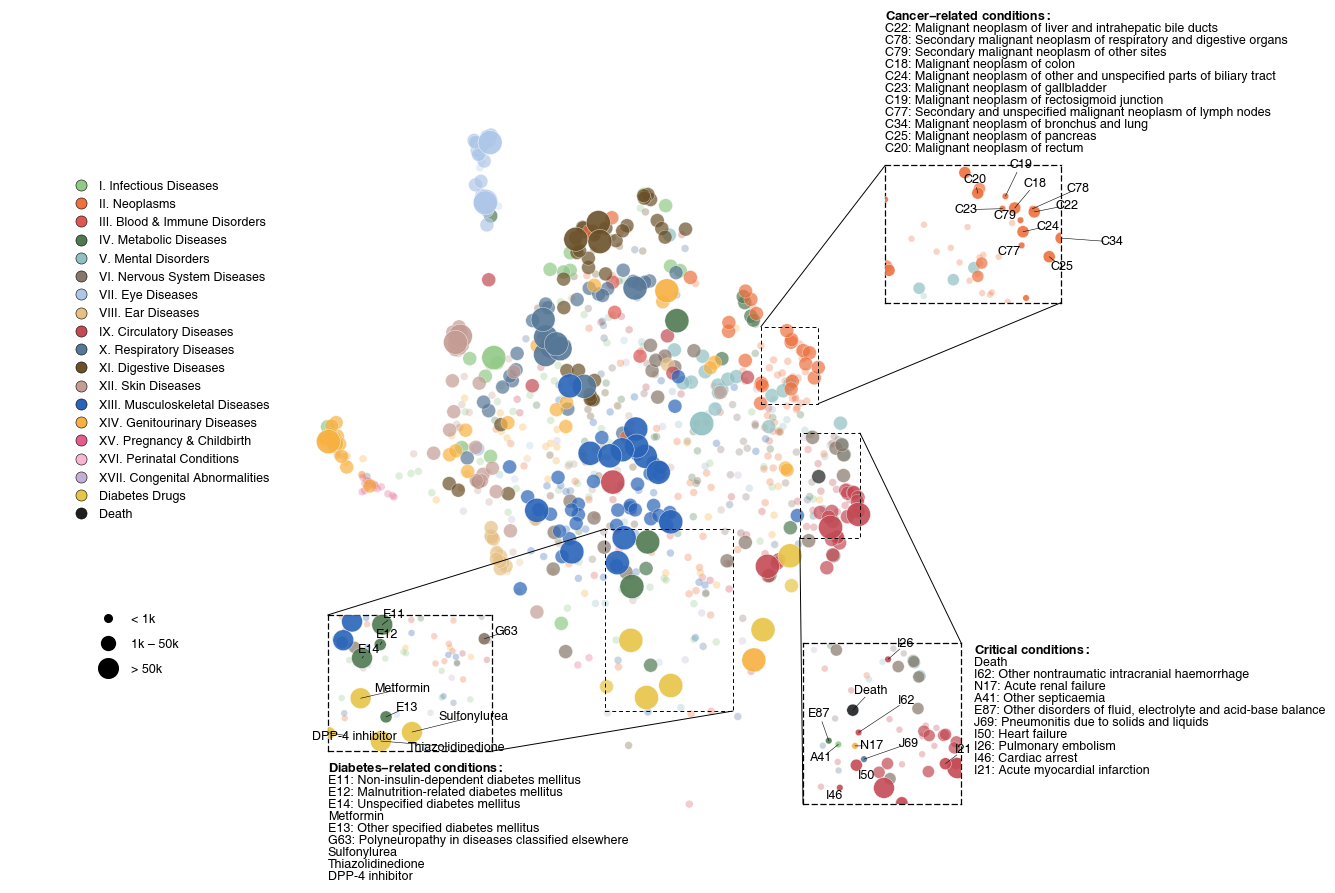

In [112]:
# TARGET_IDS = [224,225,226,227,1278,1279,1280,1281,1282,1283,1284,1285,1288,1289]

fig = draw_umap_plot(
    umap_2d, valid_ids, token_meta, token_counts, legend_info,
    # target_label_ids=TARGET_IDS,
    figsize=(11,8),
    min_event_count=MIN_EVENT_COUNT,
)
out_prefix = 'out/umap'
fig.savefig(f'{out_prefix}.pdf', dpi=900, bbox_inches='tight', pad_inches=0.25)
fig.savefig(f'{out_prefix}.png', dpi=900, bbox_inches='tight', pad_inches=0.25)
pd.DataFrame({
    'x': umap_2d[:, 0],
    'y': umap_2d[:, 1],
    'token_id': valid_ids,
    'name': [token_meta[t]['name'] for t in valid_ids],
    'chapter_short': [token_meta[t]['chapter_short'] for t in valid_ids],
    'count': [token_counts.get(t, 0) for t in valid_ids],
}).to_csv(f'{out_prefix}_coordinates.csv', index=False)
print(f'[OK] Saved {out_prefix}.png/.pdf and coordinates CSV')
plt.show()

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

# Cosine-similarity sanity check for the token representation currently used by UMAP.
emb = np.asarray(embeddings)
chapter_labels = np.array([token_meta[t]['chapter_short'] for t in valid_ids])
repr_name = globals().get('REPR_MODE', 'unknown')

sim = cosine_similarity(emb)
np.fill_diagonal(sim, np.nan)

within = []
across = []
chapter_rows = []

for chapter in pd.unique(chapter_labels):
    idx = np.where(chapter_labels == chapter)[0]
    if len(idx) < 2:
        continue

    block = sim[np.ix_(idx, idx)]
    within_vals = block[np.triu_indices(len(idx), k=1)]
    within_vals = within_vals[np.isfinite(within_vals)]
    if len(within_vals) == 0:
        continue

    other_idx = np.where(chapter_labels != chapter)[0]
    across_vals = sim[np.ix_(idx, other_idx)].ravel()
    across_vals = across_vals[np.isfinite(across_vals)]

    within.extend(within_vals.tolist())
    across.extend(across_vals.tolist())
    chapter_rows.append({
        'repr_mode': repr_name,
        'chapter_short': chapter,
        'n_tokens': len(idx),
        'within_mean': float(np.mean(within_vals)),
        'within_median': float(np.median(within_vals)),
        'across_mean': float(np.mean(across_vals)) if len(across_vals) else np.nan,
        'gap_vs_across': float(np.mean(within_vals) - np.mean(across_vals)) if len(across_vals) else np.nan,
    })

within = np.array(within)
across = np.array(across)

print(f"Representation mode:       {repr_name}")
print(f"Embedding shape:           {emb.shape}")
print(f"Within-chapter similarity: {np.nanmean(within):.4f}")
print(f"Across-chapter similarity: {np.nanmean(across):.4f}")
print(f"Gap (within - across):     {np.nanmean(within) - np.nanmean(across):.4f}")
if np.nanmean(across) != 0:
    print(f"Ratio (within / across):   {np.nanmean(within) / np.nanmean(across):.2f}x")

chapter_similarity_summary = (
    pd.DataFrame(chapter_rows)
    .sort_values(['gap_vs_across', 'within_mean'], ascending=False)
    .reset_index(drop=True)
)

chapter_similarity_summary

Representation mode:       raw
Embedding shape:           (1267, 256)
Within-chapter similarity: 0.8810
Across-chapter similarity: 0.8504
Gap (within - across):     0.0306
Ratio (within / across):   1.04x


,repr_mode,chapter_short,n_tokens,within_mean,within_median,across_mean,gap_vs_across
0,raw,XVI. Perinatal Conditions,46,0.997308,0.999474,0.914084,0.083223
1,raw,XVII. Congenital Abnormalities,87,0.985748,0.992404,0.908988,0.076760
2,raw,XV. Pregnancy & Childbirth,75,0.979122,0.991360,0.904091,0.075030
3,raw,III. Blood & Immune Disorders,34,0.942648,0.953727,0.894170,0.048479
4,raw,I. Infectious Diseases,160,0.926558,0.958198,0.882015,0.044543
5,raw,II. Neoplasms,126,0.888591,0.903636,0.862174,0.026417
6,raw,V. Mental Disorders,77,0.889678,0.907781,0.865169,0.024509
7,raw,IV. Metabolic Diseases,69,0.881940,0.930721,0.864910,0.017030
8,raw,VIII. Ear Diseases,24,0.811356,0.811946,0.794665,0.016690
9,raw,XII. Skin Diseases,71,0.836558,0.832994,0.832481,0.004076


In [65]:
# Inspect nearest tokens around Death in the current UMAP space.
import numpy as np
import pandas as pd

TOP_N_DEATH_NEAREST = 30
DEATH_TOKEN_ID = 226

_df_death = pd.DataFrame(umap_2d, columns=['x', 'y'])
_df_death['token_id'] = valid_ids
_df_death['name'] = [token_meta[t]['name'] for t in valid_ids]
_df_death['chapter_short'] = [token_meta[t]['chapter_short'] for t in valid_ids]
_df_death['count'] = [token_counts.get(t, 0) for t in valid_ids]
_df_death['code'] = _df_death['name'].astype(str).str.split().str[0].str.upper()

_min_event_count = globals().get('MIN_EVENT_COUNT', 0)
if _min_event_count and _min_event_count > 0:
    _n_before = len(_df_death)
    _df_death = _df_death[_df_death['count'] >= _min_event_count].copy()
    print(f"[INFO] Kept {len(_df_death)}/{_n_before} tokens with count >= {_min_event_count}")

if DEATH_TOKEN_ID not in set(_df_death['token_id']):
    _death_candidates = _df_death[_df_death['name'].str.lower().eq('death')]
    if _death_candidates.empty:
        _death_candidates = _df_death[_df_death['name'].str.lower().str.contains('death', na=False)]
    if _death_candidates.empty:
        raise ValueError('Death token was not found after filtering.')
    _death_row = _death_candidates.sort_values('count', ascending=False).iloc[0]
else:
    _death_row = _df_death[_df_death['token_id'] == DEATH_TOKEN_ID].iloc[0]

_df_death['dist_to_death'] = np.sqrt((_df_death['x'] - _death_row['x'])**2 + (_df_death['y'] - _death_row['y'])**2)
near_death = (
    _df_death[_df_death['token_id'] != int(_death_row['token_id'])]
    .sort_values('dist_to_death')
    .reset_index(drop=True)
)
near_death['rank'] = np.arange(1, len(near_death) + 1)

print(f"Death target: {int(_death_row['token_id'])} | {_death_row['name']} | count={int(_death_row['count'])}")
print(
    near_death[
        ['rank', 'token_id', 'code', 'name', 'chapter_short', 'count', 'dist_to_death']
    ].head(TOP_N_DEATH_NEAREST).to_string(index=False)
)

[INFO] Kept 852/1267 tokens with count >= 25
Death target: 226 | E13 Other specified diabetes mellitus | count=22009
 rank  token_id              code                                                                                                    name                  chapter_short   count  dist_to_death
    1       462               H45                               H45 Disorders of vitreous body and globe in diseases classified elsewhere              VII. Eye Diseases      31       0.114426
    2      1283 THIAZOLIDINEDIONE                                                                                       Thiazolidinedione                 Diabetes Drugs  145624       0.254185
    3      1279      SULFONYLUREA                                                                                            Sulfonylurea                 Diabetes Drugs 1467652       0.308995
    4      1278         METFORMIN                                                                                  